# Three-Class Twitter Sentiment Classifier

**Models implemented:**
- Baseline: TF-IDF + Multinomial Naive Bayes
- Neural: Embedding + CNN (1D Conv + GlobalMaxPool)

**Evaluation:**
Accuracy, Macro-F1, Per-Class F1, Confusion Matrix and Error Analysis

## 1. Setup & Dependencies

In [1]:
# Uncomment and run if packages are missing
# !pip install pandas numpy scikit-learn tensorflow matplotlib openpyxl seaborn
!pip install openpyxl -q

In [2]:
import os, re, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, f1_score,
                              classification_report, confusion_matrix)
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.preprocessing import LabelBinarizer

RANDOM_SEED = 24
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("TF version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

2026-05-02 20:32:16.782306: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777753936.981682      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777753937.036047      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777753937.519538      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777753937.519581      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777753937.519584      57 computation_placer.cc:177] computation placer alr

TF version: 2.19.0
GPU available: True


## 2. Data Loading & Preprocessing

The dataset `Twitter_Data.xlsx` has two columns: `clean_text` and `category`.
Labels: -1 = negative, 0 = neutral, 1 = positive.
We remap these to 0, 1, 2 for Keras compatibility.

In [3]:
# ── Upload Twitter_Data.xlsx to Colab, then set the path below ──
# Option A: uploaded directly
DATA_PATH = "/kaggle/input/datasets/moezurrehman24k7840/twitter-dataset/Twitter_Dataset.csv"

# Option B: if you placed it in Google Drive
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_PATH = "/content/drive/MyDrive/Twitter_Data.xlsx"

df = pd.read_csv(DATA_PATH)
print(f"Raw shape: {df.shape}")
print(df['category'].value_counts())
df = df.dropna(subset=["category"]).copy()
print(f"After dropping nulls: {df.shape}")

Raw shape: (162980, 2)
category
 1.0    72250
 0.0    55213
-1.0    35510
Name: count, dtype: int64
After dropping nulls: (162973, 2)


In [4]:
# Remap labels: -1 -> 0 (neg), 0 -> 1 (neutral), 1 -> 2 (pos)
label_map = {-1: 0, 0: 1, 1: 2}
inv_label_map = {0: 'negative', 1: 'neutral', 2: 'positive'}

df["y"] = df["category"].astype(int).map(label_map)
print("Label distribution:")
print(df["y"].value_counts().sort_index())

Label distribution:
y
0    35510
1    55213
2    72250
Name: count, dtype: int64


In [5]:
# ── Text Cleaning ──
URL_RE     = re.compile(r"http\S+|www\.\S+")
MENTION_RE = re.compile(r"@\w+")
HASHTAG_RE = re.compile(r"#(\w+)")
PUNCT_RE   = re.compile(r"[^\w\s]")

def clean_text(text: str) -> str:
    text = str(text).lower().strip()
    text = URL_RE.sub(" ", text)           # remove URLs
    text = MENTION_RE.sub(" ", text)       # remove @mentions
    text = HASHTAG_RE.sub(r"\1", text)     # keep hashtag word, drop #
    text = PUNCT_RE.sub(" ", text)         # remove punctuation
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["clean_text"].map(clean_text)
df = df[["text", "y"]].reset_index(drop=True)

print(df.head())
print(f"\nAvg token count: {df['text'].str.split().apply(len).mean():.1f}")

                                                text  y
0  when modi promised minimum government maximum ...  0
1  talk all the nonsense and continue all the dra...  1
2  what did just say vote for modi welcome bjp to...  2
3  asking his supporters prefix chowkidar their n...  2
4  answer who among these the most powerful world...  2

Avg token count: 20.0


## 3. Train / Validation / Test Split (Stratified)

Split: 70% train, 10% validation, 20% test — all stratified by label.

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    df["text"], df["y"],
    test_size=0.30, random_state=RANDOM_SEED, stratify=df["y"]
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=2/3, random_state=RANDOM_SEED, stratify=y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")
print("Train label dist:", dict(pd.Series(y_train).value_counts().sort_index()))

Train: 114081 | Val: 16297 | Test: 32595
Train label dist: {0: np.int64(24857), 1: np.int64(38649), 2: np.int64(50575)}


## 4. Baseline: TF-IDF + Multinomial Naive Bayes

In [7]:
baseline = Pipeline([
    ("tfidf", TfidfVectorizer(
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9,
        sublinear_tf=True,
        strip_accents="unicode",
        max_features=60000
    )),
    ("clf", MultinomialNB(alpha=0.1))
])

baseline.fit(X_train, y_train)

# Validation
pred_val_nb = baseline.predict(X_val)
print("=== Naive Bayes — Validation ===")
print(f"Accuracy : {accuracy_score(y_val, pred_val_nb):.4f}")
print(f"Macro-F1 : {f1_score(y_val, pred_val_nb, average='macro'):.4f}")
print(classification_report(y_val, pred_val_nb,
      target_names=['negative','neutral','positive'], digits=3))

# Test
pred_test_nb = baseline.predict(X_test)
print("=== Naive Bayes — Test ===")
print(f"Accuracy : {accuracy_score(y_test, pred_test_nb):.4f}")
print(f"Macro-F1 : {f1_score(y_test, pred_test_nb, average='macro'):.4f}")
print(classification_report(y_test, pred_test_nb,
      target_names=['negative','neutral','positive'], digits=3))

=== Naive Bayes — Validation ===
Accuracy : 0.7494
Macro-F1 : 0.7269
              precision    recall  f1-score   support

    negative      0.741     0.553     0.633      3551
     neutral      0.870     0.678     0.762      5521
    positive      0.696     0.901     0.785      7225

    accuracy                          0.749     16297
   macro avg      0.769     0.710     0.727     16297
weighted avg      0.765     0.749     0.744     16297

=== Naive Bayes — Test ===
Accuracy : 0.7518
Macro-F1 : 0.7301
              precision    recall  f1-score   support

    negative      0.747     0.561     0.641      7102
     neutral      0.871     0.677     0.762     11043
    positive      0.698     0.902     0.787     14450

    accuracy                          0.752     32595
   macro avg      0.772     0.714     0.730     32595
weighted avg      0.767     0.752     0.747     32595



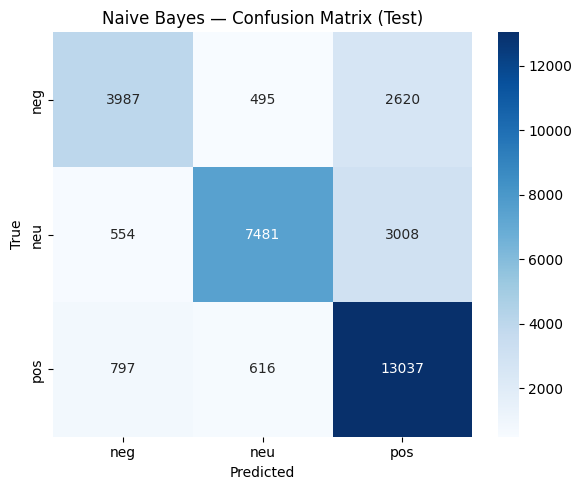

In [8]:
# Confusion matrix — Naive Bayes
cm_nb = confusion_matrix(y_test, pred_test_nb)
plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['neg','neu','pos'],
            yticklabels=['neg','neu','pos'])
plt.title("Naive Bayes — Confusion Matrix (Test)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("cm_naive_bayes.png", dpi=150)
plt.show()

## 5. Neural Model: Embedding + 1D-CNN

Architecture:
- Embedding (vocab=40k, dim=128)
- Conv1D (128 filters, kernel=3) × 2 parallel branches (kernel=3 and kernel=5)
- GlobalMaxPooling1D
- Dropout + Dense → Softmax

We use class weights to handle label imbalance.

In [9]:
# ── Tokenization ──
VOCAB_SIZE = 40000
MAX_LEN    = 64

tokenizer = keras.preprocessing.text.Tokenizer(
    num_words=VOCAB_SIZE, oov_token="<OOV>"
)
tokenizer.fit_on_texts(X_train)

def vectorize(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return keras.preprocessing.sequence.pad_sequences(
        seqs, maxlen=MAX_LEN, padding="post", truncating="post"
    )

Xtr = vectorize(X_train)
Xva = vectorize(X_val)
Xte = vectorize(X_test)

# One-hot encode labels
lb  = LabelBinarizer()
ytr = lb.fit_transform(y_train)   # (N, 3)
yva = lb.transform(y_val)
yte = lb.transform(y_test)

print(f"Xtr shape: {Xtr.shape}, ytr shape: {ytr.shape}")

Xtr shape: (114081, 64), ytr shape: (114081, 3)


In [10]:
# ── Class weights ──
classes = np.array([0, 1, 2])
cw = compute_class_weight(
    class_weight="balanced", classes=classes, y=y_train
)
class_weights = {i: w for i, w in enumerate(cw)}
print("Class weights:", class_weights)

Class weights: {0: np.float64(1.529830631210524), 1: np.float64(0.9839064400113845), 2: np.float64(0.7518932278793871)}


In [11]:
# ── Multi-kernel CNN model ──
def build_cnn(vocab_size=VOCAB_SIZE, emb_dim=128,
              max_len=MAX_LEN, num_classes=3):
    inputs = keras.Input(shape=(max_len,), dtype="int32")
    x = layers.Embedding(
        input_dim=vocab_size, output_dim=emb_dim,
        input_length=max_len
    )(inputs)

    # Two parallel convolution branches
    branch3 = layers.Conv1D(128, kernel_size=3, padding="same",
                            activation="relu")(x)
    branch3 = layers.GlobalMaxPooling1D()(branch3)

    branch5 = layers.Conv1D(128, kernel_size=5, padding="same",
                            activation="relu")(x)
    branch5 = layers.GlobalMaxPooling1D()(branch5)

    merged = layers.Concatenate()([branch3, branch5])
    merged = layers.Dropout(0.5)(merged)
    merged = layers.Dense(128, activation="relu")(merged)
    merged = layers.Dropout(0.3)(merged)
    outputs = layers.Dense(num_classes, activation="softmax")(merged)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=3e-4),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn()
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1777753978.544692      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777753978.550395      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 64, 128)   │  5,120,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 64, 128)   │     49,280 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 64, 128)   │     82,048 │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d_1[0][0]    │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3)         │        387 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,284,611 (20.16 MB)

 Trainable params: 5,284,611 (20.16 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ── Training ──
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=3, restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5
    )
]

history = cnn_model.fit(
    Xtr, ytr,
    validation_data=(Xva, yva),
    epochs=15,
    batch_size=256,
    callbacks=callbacks,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/15


I0000 00:00:1777753981.587619     141 service.cc:152] XLA service 0x7f968000b6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777753981.587656     141 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777753981.587660     141 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777753981.961849     141 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-02 20:33:03.951866: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.7 = (f32[256,128,1,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,64]{3,2,1,0} %bitcast.6824, f32[128,128,1,5]{3,2,1,0} %bitcast.6828, f32[128]{0} %bitcast.7298), window={size=1x5 pad=0_0x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv1d_1_1/convolution" source_

 19/446 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.2993 - loss: 1.0979 

I0000 00:00:1777753991.734014     141 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


445/446 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5260 - loss: 0.9109

2026-05-02 20:33:16.441121: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:33:16.742874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:33:17.252137: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:33:17.555105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-02 20:33:18.026976: E external/local_xla/xla/stream_

446/446 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5264 - loss: 0.9103

2026-05-02 20:33:23.217395: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng12{k11=2} for conv %cudnn-conv-bias-activation.7 = (f32[256,128,1,64]{3,2,1,0}, u8[0]{0}) custom-call(f32[256,128,1,64]{3,2,1,0} %bitcast.650, f32[128,128,1,5]{3,2,1,0} %bitcast.654, f32[128]{0} %bitcast.656), window={size=1x5 pad=0_0x2_2}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", metadata={op_type="Conv2D" op_name="functional_1/conv1d_1_1/convolution" source_file="/usr/local/lib/python3.12/dist-packages/tensorflow/python/framework/ops.py" source_line=1200}, backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"conv_result_scale":1,"activation_mode":"kRelu","side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false} is taking a while...
2026-05-02 20:33:23.339991: E external/local_xla/xla/service/slow_operation_alarm.cc:140] The operation took 1.122700507s
Trying algorithm en

446/446 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.5268 - loss: 0.9097 - val_accuracy: 0.9374 - val_loss: 0.2012 - learning_rate: 3.0000e-04
Epoch 2/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9403 - loss: 0.2008 - val_accuracy: 0.9629 - val_loss: 0.1246 - learning_rate: 3.0000e-04
Epoch 3/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9632 - loss: 0.1199 - val_accuracy: 0.9662 - val_loss: 0.1066 - learning_rate: 3.0000e-04
Epoch 4/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9725 - loss: 0.0852 - val_accuracy: 0.9658 - val_loss: 0.1052 - learning_rate: 3.0000e-04
Epoch 5/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9789 - loss: 0.0640 - val_accuracy: 0.9648 - val_loss: 0.1101 - learning_rate: 3.0000e-04
Epoch 6/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9833 - loss: 0.0513 - val_accuracy: 0.9641 - val_loss: 0.1235 - learning_rate: 3.0000e-04
Epoch 7/15
446/446 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9879 - 

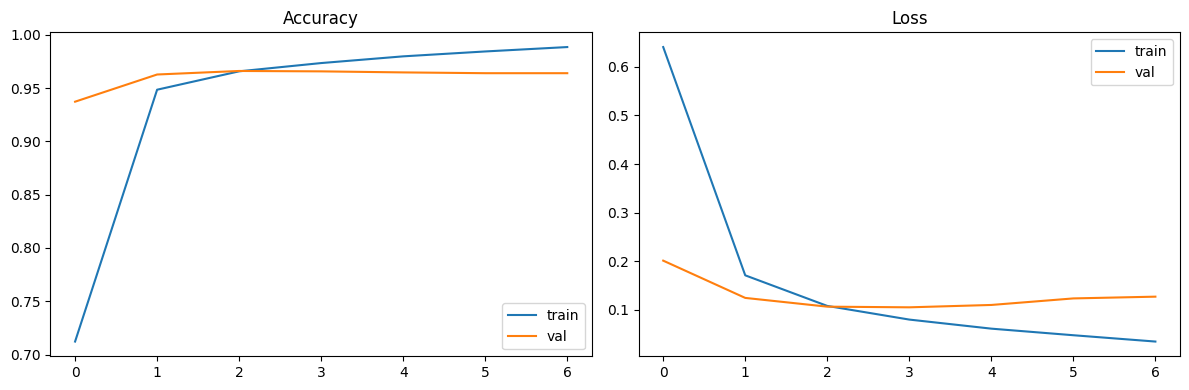

In [13]:
# ── Training curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

In [14]:
# ── CNN Evaluation ──
probs  = cnn_model.predict(Xte)
y_pred = probs.argmax(axis=1)
y_true = y_test.values

print("=== CNN — Test ===")
print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
print(f"Macro-F1 : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(classification_report(y_true, y_pred,
      target_names=['negative','neutral','positive'], digits=3))

1019/1019 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
=== CNN — Test ===
Accuracy : 0.9642
Macro-F1 : 0.9605
              precision    recall  f1-score   support

    negative      0.922     0.943     0.933      7102
     neutral      0.994     0.974     0.984     11043
    positive      0.963     0.967     0.965     14450

    accuracy                          0.964     32595
   macro avg      0.960     0.961     0.961     32595
weighted avg      0.965     0.964     0.964     32595



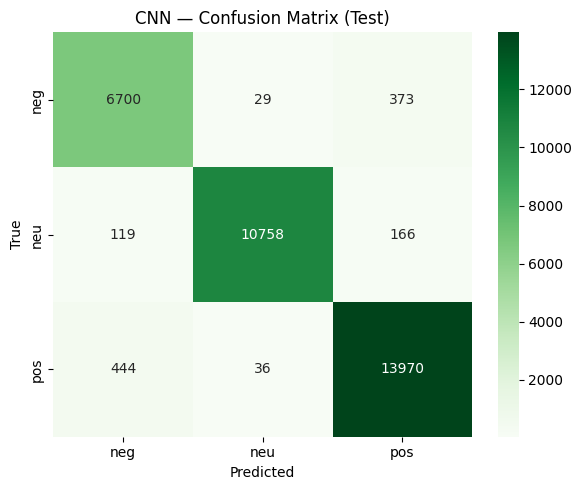

In [15]:
# ── Confusion matrix — CNN ──
cm_cnn = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['neg','neu','pos'],
            yticklabels=['neg','neu','pos'])
plt.title("CNN — Confusion Matrix (Test)")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig("cm_cnn.png", dpi=150)
plt.show()

## 6. Results Summary

In [16]:
# Side-by-side summary
nb_acc  = accuracy_score(y_test, pred_test_nb)
nb_f1   = f1_score(y_test, pred_test_nb, average='macro')
cnn_acc = accuracy_score(y_true, y_pred)
cnn_f1  = f1_score(y_true, y_pred, average='macro')

results = pd.DataFrame({
    'Model':    ['TF-IDF + Naive Bayes', 'Embedding + CNN'],
    'Accuracy': [round(nb_acc, 4), round(cnn_acc, 4)],
    'Macro-F1': [round(nb_f1,  4), round(cnn_f1,  4)]
})
print(results.to_string(index=False))

               Model  Accuracy  Macro-F1
TF-IDF + Naive Bayes    0.7518    0.7301
     Embedding + CNN    0.9642    0.9605


## 7. Error Analysis

We inspect misclassified examples from the CNN model on the test set.

In [17]:
# Collect misclassified examples
test_texts = X_test.values
misclassified = [
    (test_texts[i], y_true[i], y_pred[i])
    for i in range(len(y_true))
    if y_true[i] != y_pred[i]
]

print(f"Total misclassified: {len(misclassified)} / {len(y_true)} "
      f"({100*len(misclassified)/len(y_true):.1f}%)\n")

# Sample 10 examples, spread across error types
from collections import defaultdict
by_error = defaultdict(list)
for txt, true, pred in misclassified:
    by_error[(true, pred)].append(txt)

print("Error type counts (true, pred):")
for k, v in sorted(by_error.items()):
    t_name = inv_label_map[k[0]]
    p_name = inv_label_map[k[1]]
    print(f"  {t_name} -> {p_name}: {len(v)} examples")

Total misclassified: 1167 / 32595 (3.6%)

Error type counts (true, pred):
  negative -> neutral: 29 examples
  negative -> positive: 373 examples
  neutral -> negative: 119 examples
  neutral -> positive: 166 examples
  positive -> negative: 444 examples
  positive -> neutral: 36 examples


In [18]:
# Print 8 diverse misclassified examples
shown = 0
print("=== Sample Misclassifications ===")
for (true_lbl, pred_lbl), examples in sorted(by_error.items()):
    if shown >= 8:
        break
    t_name = inv_label_map[true_lbl]
    p_name = inv_label_map[pred_lbl]
    sample = examples[:2]
    for txt in sample:
        print(f"[True: {t_name:8s} | Pred: {p_name:8s}] {txt[:120]}")
        shown += 1

=== Sample Misclassifications ===
[True: negative | Pred: neutral ] bass modi baga
[True: negative | Pred: neutral ] your sermon drivel for votes for modi
[True: negative | Pred: positive] same way you did surgical strike surgical strike which killed 300 terrorist than mig21 shot f16 abhi just went here redu
[True: negative | Pred: positive] having weapon doesnt mean fire will mangalyan was not made and reached mars yrs and this missile only modi knows how tak
[True: neutral  | Pred: negative] modi tell when you shauchalay when you come then hand wash must soap
[True: neutral  | Pred: negative] pakistan got fitting reply for terror attacks modi govt where upa had totally failed krishna
[True: neutral  | Pred: positive] killed muslims bcz beef the akhlaq incident took place 2015 uttar pradesh state ruled then samajwadi party how modi resp
[True: neutral  | Pred: positive] modi most development india


### Error Commentary

**Neutral → Negative / Neutral → Positive:** The most common confusion. Neutral tweets often contain opinionated language without a clear overall sentiment, and the model picks up on individual words (e.g., "problem", "great") rather than the full context.

**Negative → Neutral:** Sarcasm and irony are the main culprits here. Tweets that say something positive on the surface (e.g., "wow, amazing policy") while intending criticism are difficult without pragmatic context.

**Positive → Negative:** Comparatively rare. When it does happen, it tends to be in tweets that mix criticism of one entity with praise of another — the negative words dominate the embedding representation.

The 1D-CNN lacks memory across the full sequence, which hurts on longer tweets where the sentiment pivot happens late. A BiLSTM or attention mechanism would likely recover some of these cases.